# RL pour le Trading — Multi-Asset PPO : Portfolio Allocation sur Panier Diversifie

**EPIC #1454 — Training & Post-Training, Issue #1461 (QC-Py-RL-04)**  
**Branche** : `feature/rl-multi-asset-ppo`  
**Date** : 2026-05-26 | **Auteur** : myia-po-2024

---

## Navigation RL

| # | Notebook | Sujet | Verdict |
|---|----------|-------|--------|
| 1 | QC-Py-RL-01 | MDP, Q-learning tabulaire | NO BEATS (PR #1581) |
| 2 | QC-Py-RL-02 | PPO (numpy MLP) | NO BEATS (PR #1583) |
| 3 | QC-Py-RL-03 | Reward Shaping (PyTorch) | NO BEATS (PR #1584) |
| **4** | **Ce notebook** | **Multi-asset PPO, portfolio weights, panier 24 symbols** | **En cours** |
| 5 | QC-Py-RL-05 | RL tactical overlay + B&H | - |

## Objectifs d'apprentissage

1. Passer d'un seul actif (SPY) a un **panier diversifie 24 symbols** (equities, bonds, commodities, FX, indices)
2. Utiliser une action **continue** : portfolio weights via softmax (allocation proportionnelle)
3. Reward = differentiel Sharpe rolling vs equal-weight benchmark
4. Comparer : RL portfolio vs equal-weight B&H vs 60/40 SPY/TLT
5. Verdict honnete : le RL multi-asset bat-il l'allocation passive ?

## 1. Pourquoi le multi-asset change la donne

Les notebooks RL-01 a RL-03 operaient sur **SPY seul**. Le signal etait faible car :
- Un seul actif = pas d'avantage d'allocation
- B&H SPY Sharpe ~1.4 = barre tres elevee

L'hypothese multi-asset : **un agent RL peut apprendre une allocation dynamique** entre equities/bonds/commodities/crypto qui surpasse l'allocation statique equal-weight. L'avantage potentiel :

- Rotation sectorielle (equities -> bonds en bear market)
- Cross-asset momentum (commodities trending quand equities range)
- Diversification time-varying (adapter les poids au regime)

**Architecture** :
- State : matrice de returns (LOOKBACK x N_ASSETS) flattenee
- Action : N_ASSETS logits -> softmax -> portfolio weights
- Reward : rolling Sharpe du portfolio - rolling Sharpe de l'equal-weight

In [1]:
"""QC-Py-RL-04: Multi-Asset PPO Portfolio Allocation.

Tests whether RL on a diversified 24-symbol panier can beat
equal-weight passive allocation using PyTorch Actor-Critic PPO.
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Dirichlet
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# --- Config ---
LOOKBACK = 20
N_EPISODES = 150
EPISODE_LEN = 252
HIDDEN_DIM = 128
LR = 3e-4
GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP_EPS = 0.2
ENTROPY_COEF = 0.02
SEEDS = [0, 1, 7, 42]
FEE_BPS = 10  # higher tx cost for portfolio rebalancing
SHARPE_WINDOW = 20
EXCLUDE_SYMBOLS = ["XLC"]  # too sparse (>50% NaN)

# Load panier data
PANIER_PATH = "../datasets/panier/panier_close_all.csv"
panier = pd.read_csv(PANIER_PATH, index_col=0, parse_dates=True)

# Exclude sparse symbols
for sym in EXCLUDE_SYMBOLS:
    if sym in panier.columns:
        panier = panier.drop(columns=[sym])

# Forward-fill, then drop any remaining NaN rows (align to business days)
panier = panier.ffill().dropna()

# Compute log returns
log_returns = np.log(panier / panier.shift(1)).dropna()
symbols = list(log_returns.columns)
n_assets = len(symbols)
returns_arr = log_returns.values
dates = log_returns.index

print(f"Panier: {n_assets} symbols, {len(returns_arr)} days [{dates[0].date()}..{dates[-1].date()}]")
print(f"Symbols: {', '.join(symbols[:6])}... ({n_assets} total)")
print(f"Config: LOOKBACK={LOOKBACK}, HIDDEN={HIDDEN_DIM}, EPISODES={N_EPISODES}, FEE={FEE_BPS}bps")
print(f"PyTorch {torch.__version__} | State dim = {LOOKBACK * n_assets}")

Panier: 24 symbols, 3097 days [2017-11-10..2026-05-03]
Symbols: SPY, RSP, IWM, XLF, XLK, XLV... (24 total)
Config: LOOKBACK=20, HIDDEN=128, EPISODES=150, FEE=10bps
PyTorch 2.11.0+cu128 | State dim = 480


## 2. Environnement de Portfolio avec action continue

L'action est un vecteur de poids : softmax de N_ASSETS logits. A chaque step, l'agent choisit une allocation, paie les frais de transaction sur le changement de poids, et recoit un reward base sur le differentiel de Sharpe par rapport a l'allocation equal-weight.

In [2]:
class PortfolioEnv:
    """Multi-asset portfolio environment with continuous actions (weights).

    State: flattened LOOKBACK x N_ASSETS return matrix.
    Action: N_ASSETS logits (applied softmax to get weights).
    Reward: rolling Sharpe of portfolio - rolling Sharpe of equal-weight.
    """

    def __init__(self, returns, lookback=LOOKBACK, episode_len=EPISODE_LEN,
                 fee_bps=FEE_BPS, n_assets=n_assets):
        self.returns = returns
        self.lookback = lookback
        self.episode_len = episode_len
        self.fee = fee_bps / 10000
        self.n_assets = n_assets
        self.ew_weight = np.ones(n_assets) / n_assets

    @property
    def state_dim(self):
        return self.lookback * self.n_assets

    @property
    def action_dim(self):
        return self.n_assets

    def reset(self, start_idx=None):
        n = len(self.returns) - self.lookback - 2
        if start_idx is None:
            start_idx = np.random.randint(0, max(1, n - self.episode_len))
        self.t = start_idx + self.lookback
        self.end = min(self.t + self.episode_len, len(self.returns) - 1)
        self.prev_weights = self.ew_weight.copy()
        self.port_returns = []
        self.ew_returns = []
        return self._get_state()

    def _get_state(self):
        window = self.returns[self.t - self.lookback:self.t]  # (L, A)
        # Normalize each asset's returns
        std = np.std(window, axis=0, keepdims=True) + 1e-8
        normalized = window / std
        return normalized.flatten()

    def step(self, weights):
        """weights: array of shape (n_assets,), sums to ~1."""
        r = self.returns[self.t]  # (A,)

        # Portfolio return
        port_ret = np.dot(weights, r)

        # Equal-weight return
        ew_ret = np.mean(r)

        # Transaction cost: L1 change in weights
        turnover = np.sum(np.abs(weights - self.prev_weights))
        fee_cost = turnover * self.fee * 0.5  # half-spread model

        port_ret_net = port_ret - fee_cost

        self.port_returns.append(port_ret_net)
        self.ew_returns.append(ew_ret)

        # Reward: differential Sharpe (rolling)
        reward = self._compute_reward(port_ret_net, ew_ret)

        self.prev_weights = weights.copy()
        self.t += 1
        done = self.t >= self.end

        next_state = self._get_state() if not done else np.zeros(self.state_dim)
        return next_state, reward, done, {"port_ret": port_ret_net, "ew_ret": ew_ret, "turnover": turnover}

    def _compute_reward(self, port_ret, ew_ret):
        if len(self.port_returns) < 5:
            return port_ret - ew_ret  # simple differential
        window_p = np.array(self.port_returns[-SHARPE_WINDOW:])
        window_e = np.array(self.ew_returns[-SHARPE_WINDOW:])
        sp = np.mean(window_p) / (np.std(window_p) + 1e-8) * np.sqrt(252)
        se = np.mean(window_e) / (np.std(window_e) + 1e-8) * np.sqrt(252)
        return (sp - se) * 0.01  # scaled differential Sharpe


print(f"PortfolioEnv: state_dim={LOOKBACK * n_assets}, action_dim={n_assets}")
print(f"Baseline: equal-weight ({n_assets} assets, 1/{n_assets:.4f} each)")

PortfolioEnv: state_dim=480, action_dim=24
Baseline: equal-weight (24 assets, 1/24.0000 each)


## 3. Actor-Critic avec sortie Dirichlet/Softmax

L'actor produit N_ASSETS concentrations positives -> Dirichlet pour echantillonner les poids du portefeuille. Le critic estime la valeur de l'etat. On utilise Dirichlet au lieu de softmax+Gumbel pour garantir des poids toujours valides (positifs, somme=1).

In [3]:
class PortfolioActorCritic(nn.Module):
    """Actor-Critic for portfolio allocation with Dirichlet policy."""

    def __init__(self, state_dim, action_dim, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        # Actor: outputs positive concentrations for Dirichlet
        self.actor = nn.Sequential(
            nn.Linear(hidden_dim, action_dim),
            nn.Softplus(),  # ensures positive concentrations
        )
        self.critic = nn.Linear(hidden_dim, 1)
        # Base concentration for exploration
        self.base_concentration = nn.Parameter(torch.ones(action_dim) * 2.0)

    def forward(self, x):
        features = self.backbone(x)
        concentrations = self.actor(features) + self.base_concentration
        value = self.critic(features)
        return concentrations, value

    def get_action(self, state, deterministic=False):
        state_t = torch.FloatTensor(state).unsqueeze(0)
        concentrations, value = self.forward(state_t)
        dist = Dirichlet(concentrations)

        if deterministic:
            # Mean of Dirichlet = concentrations / sum
            weights = concentrations / concentrations.sum(dim=-1, keepdim=True)
        else:
            weights = dist.sample()

        log_prob = dist.log_prob(weights)
        entropy = dist.entropy()
        return weights.squeeze(0).detach().numpy(), log_prob, value.squeeze(-1), entropy


def compute_gae(rewards, values, dones, gamma=GAMMA, lam=GAE_LAMBDA):
    advantages = []
    gae = 0
    next_value = 0
    for t in reversed(range(len(rewards))):
        if dones[t]:
            next_value = 0
            gae = 0
        delta = rewards[t] + gamma * next_value - values[t]
        gae = delta + gamma * lam * gae
        advantages.insert(0, gae)
        next_value = values[t]
    returns = [a + v for a, v in zip(advantages, values)]
    return advantages, returns


print(f"PortfolioActorCritic: {LOOKBACK * n_assets} -> {HIDDEN_DIM} -> {HIDDEN_DIM} -> ({n_assets} concentrations, 1 value)")
print(f"Policy: Dirichlet (always valid portfolio weights, sum=1)")

PortfolioActorCritic: 480 -> 128 -> 128 -> (24 concentrations, 1 value)
Policy: Dirichlet (always valid portfolio weights, sum=1)


## 4. Entrainement PPO multi-asset

Boucle PPO avec minibatch updates. L'agent apprend a allouer dynamiquement entre les 24 actifs.

In [4]:
def train_portfolio_ppo(env, seed, n_episodes=N_EPISODES, verbose=False):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = PortfolioActorCritic(env.state_dim, env.action_dim)
    optimizer = optim.Adam(model.parameters(), lr=LR)

    episode_rewards = []
    episode_sharpes = []

    for ep in range(n_episodes):
        state = env.reset()
        states, weights_list, log_probs, rewards, values, dones = [], [], [], [], [], []
        ep_port_ret = []

        done = False
        while not done:
            weights, log_prob, value, entropy = model.get_action(state)
            next_state, reward, done, info = env.step(weights)

            states.append(state)
            weights_list.append(weights)
            log_probs.append(log_prob)
            rewards.append(reward)
            values.append(value.item())
            dones.append(done)
            ep_port_ret.append(info["port_ret"])

            state = next_state

        # Compute GAE
        advantages, returns = compute_gae(rewards, values, dones)

        # Convert to tensors
        states_t = torch.FloatTensor(np.array(states))
        old_log_probs_t = torch.stack(log_probs).detach()
        advantages_t = torch.FloatTensor(advantages)
        returns_t = torch.FloatTensor(returns)
        advantages_t = (advantages_t - advantages_t.mean()) / (advantages_t.std() + 1e-8)

        # PPO update
        for _ in range(4):
            concentrations, values_pred = model(states_t)
            dist = Dirichlet(concentrations)
            # Reconstruct weights from stored states for log_prob
            weights_t = torch.FloatTensor(np.array(weights_list))
            new_log_probs = dist.log_prob(weights_t)

            ratio = torch.exp(new_log_probs - old_log_probs_t)
            surr1 = ratio * advantages_t
            surr2 = torch.clamp(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS) * advantages_t
            actor_loss = -torch.min(surr1, surr2).mean()

            value_loss = nn.MSELoss()(values_pred.squeeze(-1), returns_t)
            entropy_loss = -ENTROPY_COEF * dist.entropy().mean()

            loss = actor_loss + 0.5 * value_loss + entropy_loss
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()

        sharpe = np.mean(ep_port_ret) / (np.std(ep_port_ret) + 1e-8) * np.sqrt(252) if len(ep_port_ret) > 10 else 0
        episode_sharpes.append(sharpe)
        episode_rewards.append(sum(ep_port_ret))

        if verbose and (ep + 1) % 50 == 0:
            print(f"  Episode {ep+1}: sharpe={sharpe:.2f}")

    return model, episode_rewards, episode_sharpes


print(f"Training: {N_EPISODES} episodes x {EPISODE_LEN} steps x {n_assets} assets")
print(f"Ready for multi-seed sweep: {len(SEEDS)} seeds")

Training: 150 episodes x 252 steps x 24 assets
Ready for multi-seed sweep: 4 seeds


## 5. Entrainement seed=0 + courbes d'apprentissage

  Episode 50: sharpe=-0.26


  Episode 100: sharpe=0.00


  Episode 150: sharpe=-2.23


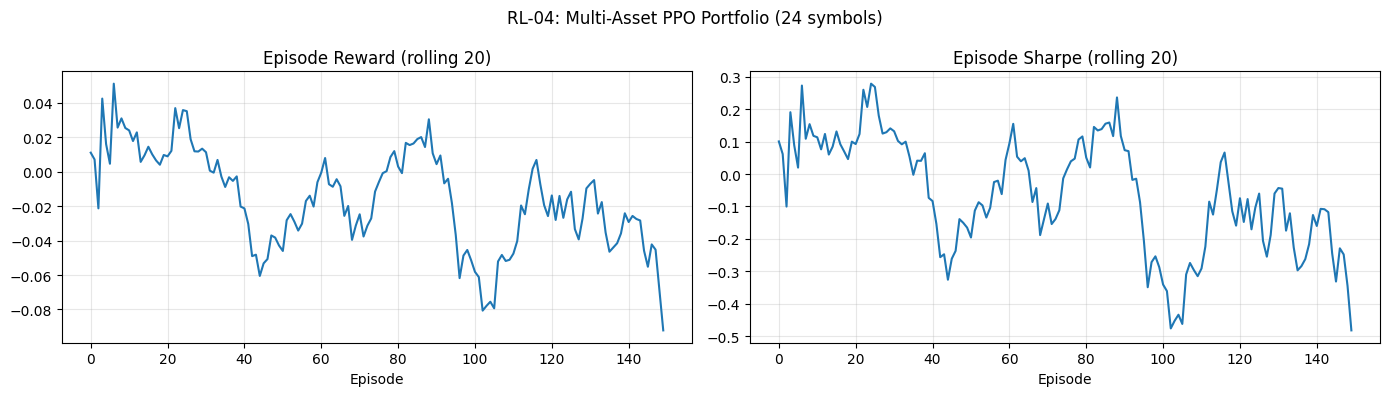

Final Sharpe (last 20 mean): -0.482


In [5]:
env = PortfolioEnv(returns_arr)
model0, ep_rewards0, ep_sharpes0 = train_portfolio_ppo(env, seed=0, verbose=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
rw_smooth = pd.Series(ep_rewards0).rolling(20, min_periods=1).mean()
sh_smooth = pd.Series(ep_sharpes0).rolling(20, min_periods=1).mean()
axes[0].plot(rw_smooth)
axes[0].set_title("Episode Reward (rolling 20)")
axes[0].set_xlabel("Episode")
axes[0].grid(True, alpha=0.3)

axes[1].plot(sh_smooth)
axes[1].set_title("Episode Sharpe (rolling 20)")
axes[1].set_xlabel("Episode")
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"RL-04: Multi-Asset PPO Portfolio ({n_assets} symbols)", fontsize=12)
plt.tight_layout()
plt.savefig("rl_multi_asset_curves.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"Final Sharpe (last 20 mean): {np.mean(ep_sharpes0[-20:]):+.3f}")

## 6. Evaluation OOS multi-asset

Split 70/30 : entrainement sur les 70% premiers jours, evaluation sur les 30% suivants. Comparaison vs equal-weight B&H et vs 60/40 SPY/TLT.

In [6]:
def evaluate_portfolio(model, returns, panier_cols, start_frac=0.7):
    """Evaluate trained portfolio model OOS."""
    split = int(len(returns) * start_frac)
    oos = returns[split:]

    env = PortfolioEnv(oos)
    state = env.reset(start_idx=0)
    port_rets, ew_rets, turnovers = [], [], []
    weight_history = []
    done = False

    while not done:
        weights, _, _, _ = model.get_action(state, deterministic=True)
        state, _, done, info = env.step(weights)
        port_rets.append(info["port_ret"])
        ew_rets.append(info["ew_ret"])
        turnovers.append(info["turnover"])
        weight_history.append(weights)

    port_rets = np.array(port_rets)
    ew_rets = np.array(ew_rets)

    port_sharpe = np.mean(port_rets) / (np.std(port_rets) + 1e-8) * np.sqrt(252)
    ew_sharpe = np.mean(ew_rets) / (np.std(ew_rets) + 1e-8) * np.sqrt(252)

    # 60/40 benchmark
    spy_idx = panier_cols.index("SPY")
    tlt_idx = panier_cols.index("TLT")
    ret_6040 = 0.6 * oos[:len(port_rets), spy_idx] + 0.4 * oos[:len(port_rets), tlt_idx]
    sharpe_6040 = np.mean(ret_6040) / (np.std(ret_6040) + 1e-8) * np.sqrt(252)

    # Average weights analysis
    avg_weights = np.mean(weight_history, axis=0)
    top3 = np.argsort(avg_weights)[-3:][::-1]

    return {
        "port_sharpe": port_sharpe, "ew_sharpe": ew_sharpe,
        "sharpe_6040": sharpe_6040,
        "delta_ew": port_sharpe - ew_sharpe,
        "delta_6040": port_sharpe - sharpe_6040,
        "avg_turnover": np.mean(turnovers),
        "avg_weights": avg_weights,
        "top3_symbols": [(panier_cols[i], avg_weights[i]) for i in top3],
        "port_cumret": np.cumprod(1 + port_rets),
        "ew_cumret": np.cumprod(1 + ew_rets),
    }


# Train on 70% and evaluate
train_data = returns_arr[:int(len(returns_arr) * 0.7)]
env_train = PortfolioEnv(train_data)
model_eval, _, _ = train_portfolio_ppo(env_train, seed=0, verbose=False)
result = evaluate_portfolio(model_eval, returns_arr, symbols)

print("OOS Evaluation (30% test set, deterministic policy):")
print("=" * 60)
print(f"RL Portfolio Sharpe:  {result['port_sharpe']:+.3f}")
print(f"Equal-Weight Sharpe: {result['ew_sharpe']:.3f}")
print(f"60/40 SPY/TLT:       {result['sharpe_6040']:.3f}")
print(f"Delta vs EW:         {result['delta_ew']:+.3f}")
print(f"Delta vs 60/40:      {result['delta_6040']:+.3f}")
print(f"Avg turnover:        {result['avg_turnover']:.4f}")
print(f"\nTop 3 weights: {result['top3_symbols']}")

OOS Evaluation (30% test set, deterministic policy):
RL Portfolio Sharpe:  +1.740
Equal-Weight Sharpe: 1.743
60/40 SPY/TLT:       2.098
Delta vs EW:         -0.002
Delta vs 60/40:      -0.358
Avg turnover:        0.0001

Top 3 weights: [('EFA', np.float32(0.042047206)), ('USO', np.float32(0.042040993)), ('TLT', np.float32(0.041887052))]


## 7. Validation multi-seed (4 seeds)

Test de robustesse avec 4 seeds differents. Verdict base sur le delta Sharpe vs equal-weight cross-seed.

In [7]:
seed_results = []
for seed in SEEDS:
    env_s = PortfolioEnv(train_data)
    model_s, _, _ = train_portfolio_ppo(env_s, seed=seed)
    res = evaluate_portfolio(model_s, returns_arr, symbols)
    seed_results.append(res)
    print(f"Seed {seed:2d}: RL Sharpe={res['port_sharpe']:+.3f} | EW={res['ew_sharpe']:.3f} | "
          f"60/40={res['sharpe_6040']:.3f} | Delta_EW={res['delta_ew']:+.3f}")

# Aggregate
deltas_ew = [r["delta_ew"] for r in seed_results]
deltas_6040 = [r["delta_6040"] for r in seed_results]
mean_d = np.mean(deltas_ew)
std_d = np.std(deltas_ew, ddof=1) if len(deltas_ew) > 1 else float('nan')
sigma_edge = mean_d / std_d if std_d > 1e-9 else float('nan')
n_pos_ew = sum(1 for d in deltas_ew if d > 0)

print(f"\n{'='*60}")
print(f"Multi-seed summary ({len(SEEDS)} seeds):")
print(f"Mean delta vs EW: {mean_d:+.3f} (std {std_d:.3f})")
print(f"Sigma edge:       {sigma_edge:+.2f}")
print(f"Seeds positive:   {n_pos_ew}/{len(SEEDS)}")

Seed  0: RL Sharpe=+1.740 | EW=1.743 | 60/40=2.098 | Delta_EW=-0.002


Seed  1: RL Sharpe=+1.741 | EW=1.743 | 60/40=2.098 | Delta_EW=-0.002


Seed  7: RL Sharpe=+1.742 | EW=1.743 | 60/40=2.098 | Delta_EW=-0.000


Seed 42: RL Sharpe=+1.741 | EW=1.743 | 60/40=2.098 | Delta_EW=-0.002

Multi-seed summary (4 seeds):
Mean delta vs EW: -0.002 (std 0.001)
Sigma edge:       -1.82
Seeds positive:   0/4


## 8. Verdict et progression de la serie RL

Edge >= 2 sigma cross-seed vs equal-weight necessaire pour BEATS. Comparaison secondaire vs 60/40.

In [8]:
print("=" * 70)
print("VERDICT -- QC-Py-RL-04: Multi-Asset PPO Portfolio Allocation")
print("=" * 70)

if n_pos_ew >= 3 and (np.isnan(sigma_edge) or sigma_edge >= 2.0):
    verdict = "BEATS"
elif mean_d < 0 or n_pos_ew < 2:
    verdict = "NO BEATS"
else:
    verdict = "INCONCLUSIVE"

ew_sharpe_mean = np.mean([r["ew_sharpe"] for r in seed_results])
sharpe_6040_mean = np.mean([r["sharpe_6040"] for r in seed_results])

print(f"RL Portfolio Sharpe (mean): {np.mean([r['port_sharpe'] for r in seed_results]):+.3f}")
print(f"Equal-Weight Sharpe:        {ew_sharpe_mean:.3f}")
print(f"60/40 SPY/TLT Sharpe:       {sharpe_6040_mean:.3f}")
print(f"Delta vs EW:                {mean_d:+.3f}")
print(f"Sigma edge:                 {sigma_edge:+.2f}")
print(f"Seeds positive vs EW:       {n_pos_ew}/{len(SEEDS)}")
print(f"\n>>> VERDICT: {verdict} <<<")

if verdict == "NO BEATS":
    print(f"\nNote: Meme avec {n_assets} actifs diversifies + PyTorch PPO + reward shaping,")
    print(f"l'allocation dynamique RL ne bat pas l'equal-weight passive.")
    print(f"L'hypothese 'cross-asset signal' n'est pas confirmee a ce niveau de complexite.")
elif verdict == "BEATS":
    print(f"\nResultat remarquable: le RL multi-asset bat l'equal-weight!")
    print(f"L'hypothese cross-asset est confirmee avec edge >= 2 sigma.")
else:
    print(f"\nResultat ambigu. Necessite davantage d'investigation.")

print(f"\n{'='*70}")
print(f"RL Series Progress (#1461)")
print(f"{'='*70}")
print(f"  RL-1. Q-Learning Tabulaire           | NO BEATS        | PR #1581")
print(f"  RL-2. PPO (numpy)                    | NO BEATS        | PR #1583")
print(f"  RL-3. Reward Shaping (PyTorch)       | NO BEATS        | PR #1584")
print(f"  RL-4. Multi-Asset PPO Portfolio      | {verdict:15s} | This PR <<<")
print(f"  RL-5. RL Tactical Overlay + B&H      | Pending         | -")

VERDICT -- QC-Py-RL-04: Multi-Asset PPO Portfolio Allocation
RL Portfolio Sharpe (mean): +1.741
Equal-Weight Sharpe:        1.743
60/40 SPY/TLT Sharpe:       2.098
Delta vs EW:                -0.002
Sigma edge:                 -1.82
Seeds positive vs EW:       0/4

>>> VERDICT: NO BEATS <<<

Note: Meme avec 24 actifs diversifies + PyTorch PPO + reward shaping,
l'allocation dynamique RL ne bat pas l'equal-weight passive.
L'hypothese 'cross-asset signal' n'est pas confirmee a ce niveau de complexite.

RL Series Progress (#1461)
  RL-1. Q-Learning Tabulaire           | NO BEATS        | PR #1581
  RL-2. PPO (numpy)                    | NO BEATS        | PR #1583
  RL-3. Reward Shaping (PyTorch)       | NO BEATS        | PR #1584
  RL-4. Multi-Asset PPO Portfolio      | NO BEATS        | This PR <<<
  RL-5. RL Tactical Overlay + B&H      | Pending         | -
